Import


In [10]:
from pathlib import Path
from PIL import Image
from collections import Counter
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Path


In [11]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CLASS_NAMES = {
    0: "Platelets",
    1: "RBC",
    2: "WBC"
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("Processed exists:", PROCESSED_DIR.exists())

PROJECT_ROOT: d:\IT\AI Microscope Blood Cell Detection System
PROCESSED_DIR: d:\IT\AI Microscope Blood Cell Detection System\data\processed
Processed exists: True


In [12]:
for path in PROCESSED_DIR.rglob("*"):
    print(path)

d:\IT\AI Microscope Blood Cell Detection System\data\processed\data.yaml
d:\IT\AI Microscope Blood Cell Detection System\data\processed\images
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels
d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\test
d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\train
d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\val
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\test
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\train
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\val
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\test\BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8.txt
d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\test\BloodImage_00044_jpg.rf.e7760375eba4bc20c5746367e2311e18.txt
d:\IT\AI Microscope Blood Cell Detection System\data\processed\la

Check the image for the corresponding label.

In [13]:
def get_image_paths(image_dir):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    image_paths = []

    for ext in extensions:
        image_paths.extend(image_dir.glob(ext))

    return sorted(image_paths)

def check_image_label_pairs(split):
    image_dir = PROCESSED_DIR / "images" / split
    label_dir = PROCESSED_DIR / "labels" / split

    image_paths = get_image_paths(image_dir)

    missing_labels = []

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels.append(image_path)

    return image_paths, missing_labels


for split in ["train", "val", "test"]:
    image_paths, missing_labels = check_image_label_pairs(split)

    print(split)
    print("Images:", len(image_paths))
    print("Missing labels:", len(missing_labels))
    print()

train
Images: 1530
Missing labels: 0

val
Images: 146
Missing labels: 0

test
Images: 72
Missing labels: 0



Check for empty labels.

In [14]:
def check_empty_labels(split):
    label_dir = PROCESSED_DIR / "labels" / split
    label_paths = list(label_dir.glob("*.txt"))

    empty_labels = []

    for label_path in label_paths:
        if label_path.stat().st_size == 0:
            empty_labels.append(label_path)

    return empty_labels


for split in ["train", "val", "test"]:
    empty_labels = check_empty_labels(split)

    print(split)
    print("Empty labels:", len(empty_labels))
    print()

train
Empty labels: 0

val
Empty labels: 0

test
Empty labels: 0



Check for corrupted images.

In [15]:
def check_corrupt_images(split):
    image_dir = PROCESSED_DIR / "images" / split
    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpeg"))

    corrupt_images = []

    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupt_images.append(image_path)

    return corrupt_images


for split in ["train", "val", "test"]:
    corrupt_images = check_corrupt_images(split)

    print(split)
    print("Corrupt images:", len(corrupt_images))
    print()

train
Corrupt images: 0

val
Corrupt images: 0

test
Corrupt images: 0



Check class distribution

In [16]:
def count_objects(split):
    label_dir = PROCESSED_DIR / "labels" / split
    label_paths = list(label_dir.glob("*.txt"))

    counter = Counter()

    for label_path in label_paths:
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            counter[class_id] += 1

    return counter


for split in ["train", "val", "test"]:
    counter = count_objects(split)

    print(split)

    for class_id, count in counter.items():
        print(CLASS_NAMES[class_id], count)

    print()

train
WBC 789
RBC 8814
Platelets 739

val
WBC 72
RBC 819
Platelets 76

test
WBC 37
RBC 398
Platelets 36



Visualize the processed annotation test

In [17]:
def read_yolo_labels(label_path):
    boxes = []

    if not label_path.exists():
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        boxes.append({
            "class_id": int(parts[0]),
            "x_center": float(parts[1]),
            "y_center": float(parts[2]),
            "width": float(parts[3]),
            "height": float(parts[4])
        })

    return boxes


def visualize_processed_image(split="train"):
    image_dir = PROCESSED_DIR / "images" / split
    label_dir = PROCESSED_DIR / "labels" / split

    print("Image dir:", image_dir)
    print("Label dir:", label_dir)
    print("Image dir exists:", image_dir.exists())
    print("Label dir exists:", label_dir.exists())

    image_paths = get_image_paths(image_dir)

    print("Number of images:", len(image_paths))

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"No images found in {image_dir}. "
            "Check PROCESSED_DIR or make sure you already created the processed dataset."
        )

    image_path = random.choice(image_paths)
    label_path = label_dir / f"{image_path.stem}.txt"

    print("Selected image:", image_path)
    print("Selected label:", label_path)
    print("Label exists:", label_path.exists())

    image = Image.open(image_path).convert("RGB")
    image_width, image_height = image.size

    boxes = read_yolo_labels(label_path)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)

    for box in boxes:
        class_id = box["class_id"]

        x_center = box["x_center"] * image_width
        y_center = box["y_center"] * image_height
        box_width = box["width"] * image_width
        box_height = box["height"] * image_height

        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2

        rect = patches.Rectangle(
            (x1, y1),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        label_name = CLASS_NAMES.get(class_id, f"class_{class_id}")

        ax.text(
            x1,
            y1 - 5,
            label_name,
            fontsize=10,
            color="yellow",
            bbox=dict(facecolor="black", alpha=0.5)
        )

    ax.set_title(f"{split} - {image_path.name}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return fig

Image dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\train
Label dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\train
Image dir exists: True
Label dir exists: True
Number of images: 1530
Selected image: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\train\BloodImage_00243_jpg.rf.6ba792036e4e588b0d56bd4e39545172.jpg
Selected label: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\train\BloodImage_00243_jpg.rf.6ba792036e4e588b0d56bd4e39545172.txt
Label exists: True


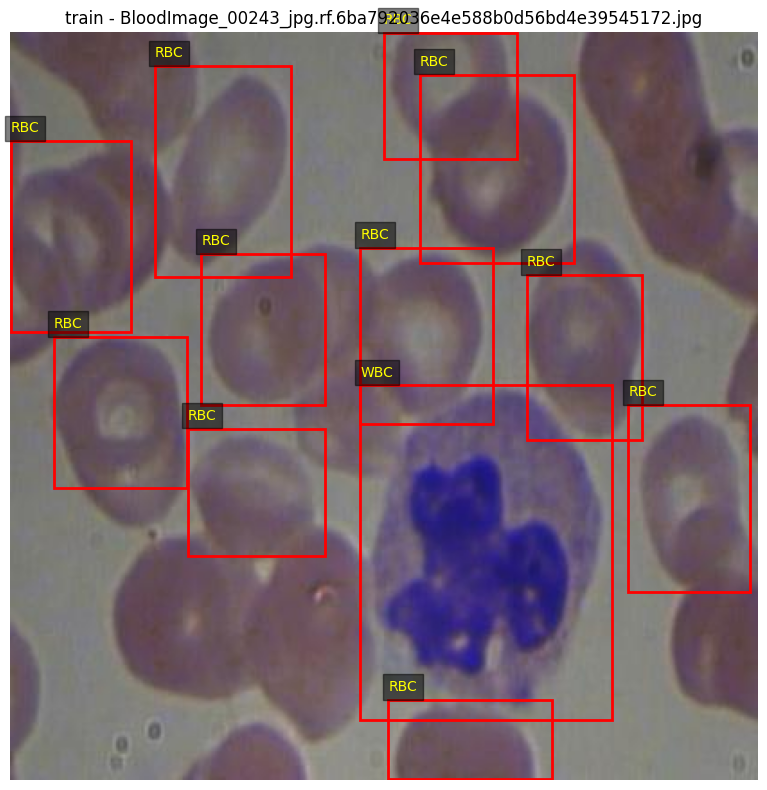

In [21]:
fig = visualize_processed_image("train")


Image dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\val
Label dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\val
Image dir exists: True
Label dir exists: True
Number of images: 146
Selected image: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\val\BloodImage_00225_jpg.rf.67a62663e8236df12256744cbde76595.jpg
Selected label: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\val\BloodImage_00225_jpg.rf.67a62663e8236df12256744cbde76595.txt
Label exists: True


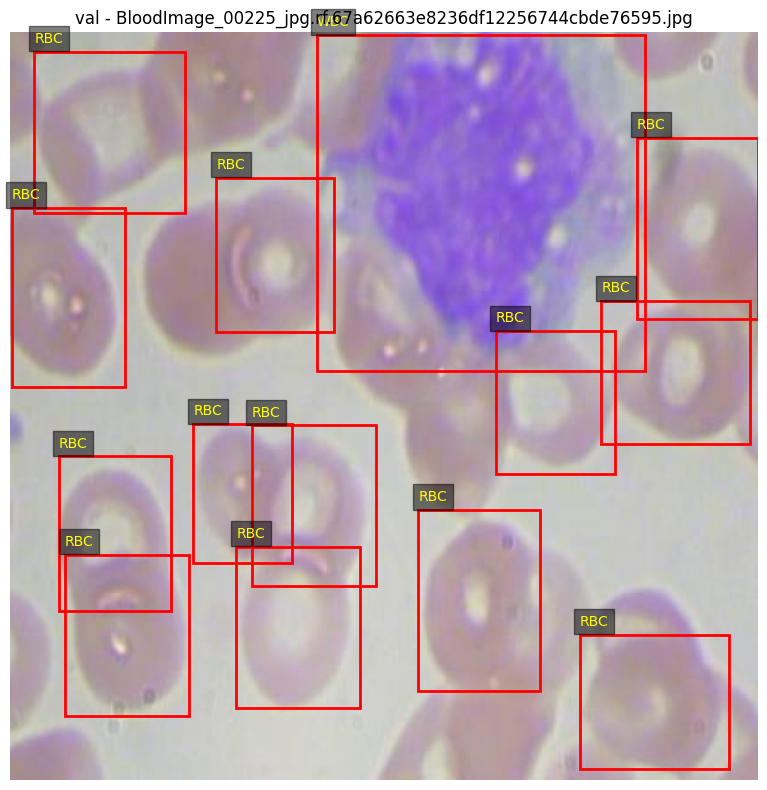

In [22]:
fig = visualize_processed_image("val")


Image dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\test
Label dir: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\test
Image dir exists: True
Label dir exists: True
Number of images: 72
Selected image: d:\IT\AI Microscope Blood Cell Detection System\data\processed\images\test\BloodImage_00336_jpg.rf.8d3e710e8696c10bcbb101dc8a553ca0.jpg
Selected label: d:\IT\AI Microscope Blood Cell Detection System\data\processed\labels\test\BloodImage_00336_jpg.rf.8d3e710e8696c10bcbb101dc8a553ca0.txt
Label exists: True


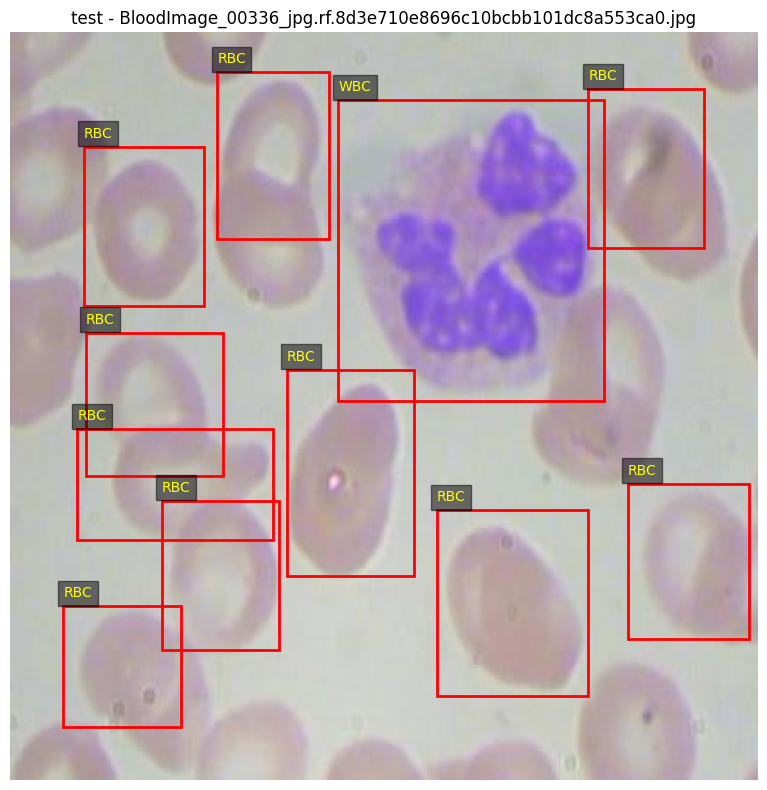

In [23]:
fig = visualize_processed_image("test")
